In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# dataset
df = pd.read_csv('student-scores.csv')
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [56]:
print(df.columns.tolist())

['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job', 'absence_days', 'extracurricular_activities', 'weekly_self_study_hours', 'career_aspiration', 'math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']


In [57]:
cols_to_drop = ['id', 'first_name', 'last_name', 'email', 'career_aspiration'] 
df_simple = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [58]:
df_encoded = pd.get_dummies(df_simple, drop_first=True)
print("новое количество колонок:", df_encoded.shape[1])

новое количество колонок: 12


In [59]:
print(df_encoded.columns.tolist())

['part_time_job', 'absence_days', 'extracurricular_activities', 'weekly_self_study_hours', 'math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score', 'gender_male']


In [60]:
print(df_encoded.shape)

(2000, 12)


In [61]:
df_encoded.head()


,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score,gender_male
0,False,3,False,27,73,81,93,97,63,80,87,True
1,False,2,False,47,90,86,96,100,90,88,90,False
2,False,9,True,13,81,97,95,96,65,77,94,False
3,False,5,False,3,71,74,88,80,89,63,86,False
4,False,5,False,10,84,77,65,65,80,74,76,True


In [62]:
# Calculate the correlation of all features with weekly_self_study_hours
correlations = df_encoded.corr()['weekly_self_study_hours'].sort_values(ascending=False)

print("Correlation with Weekly Self Study Hours:")
print(correlations)

Correlation with Weekly Self Study Hours:
weekly_self_study_hours       1.000000
math_score                    0.393569
history_score                 0.276231
english_score                 0.247796
physics_score                 0.202120
chemistry_score               0.201340
biology_score                 0.190481
geography_score               0.153622
gender_male                   0.077104
extracurricular_activities   -0.052515
part_time_job                -0.213963
absence_days                 -0.286086
Name: weekly_self_study_hours, dtype: float64


In [63]:
features = ['weekly_self_study_hours', 'math_score', 'history_score', 'english_score', 'physics_score'] 
X = df_encoded[features]  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("final features:", X.shape[1])

final features: 5


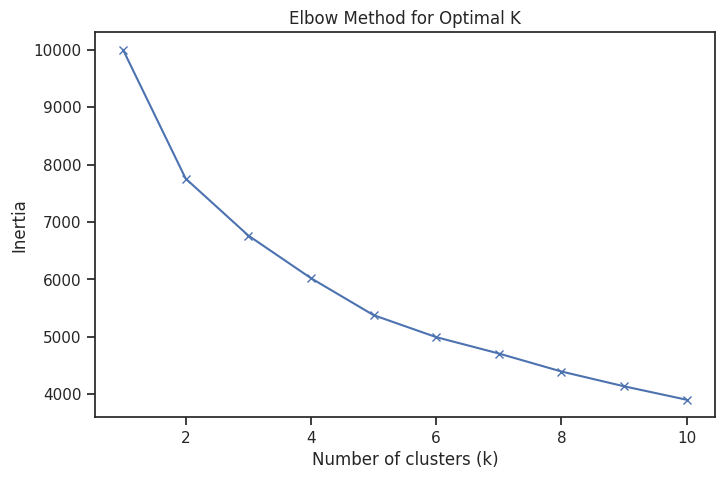

In [64]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [69]:
# Task C: Comparing multiple K values
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    print(f"For K={k}, Inertia is: {km.inertia_:.2f}")

# Выбираем оптимальное K на основе графика и сравнения
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster_label'] = kmeans_final.fit_predict(X_scaled)

For K=2, Inertia is: 7755.61
For K=3, Inertia is: 6764.61
For K=4, Inertia is: 6022.15
For K=5, Inertia is: 5377.93


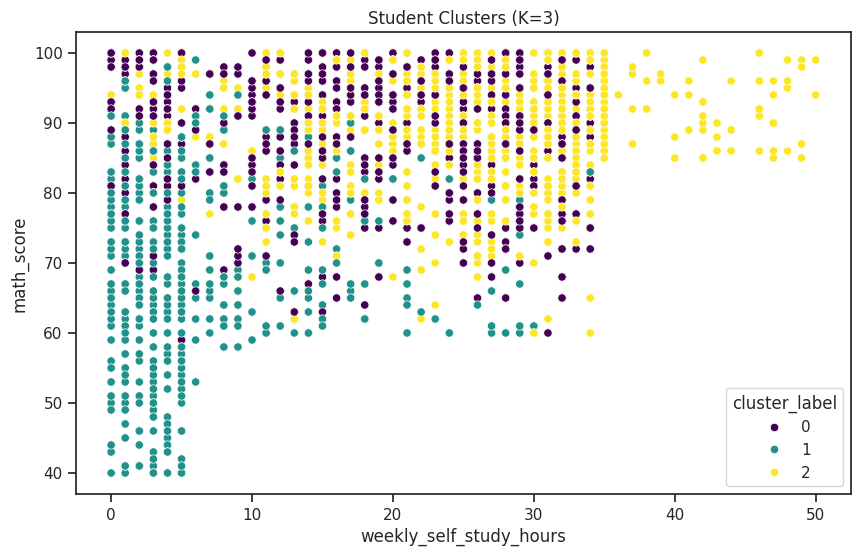

In [66]:
# Визуализация 1: Распределение кластеров по двум признакам (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weekly_self_study_hours', y='math_score', hue='cluster_label', palette='viridis')
plt.title(f'Student Clusters (K={optimal_k})')
plt.show()

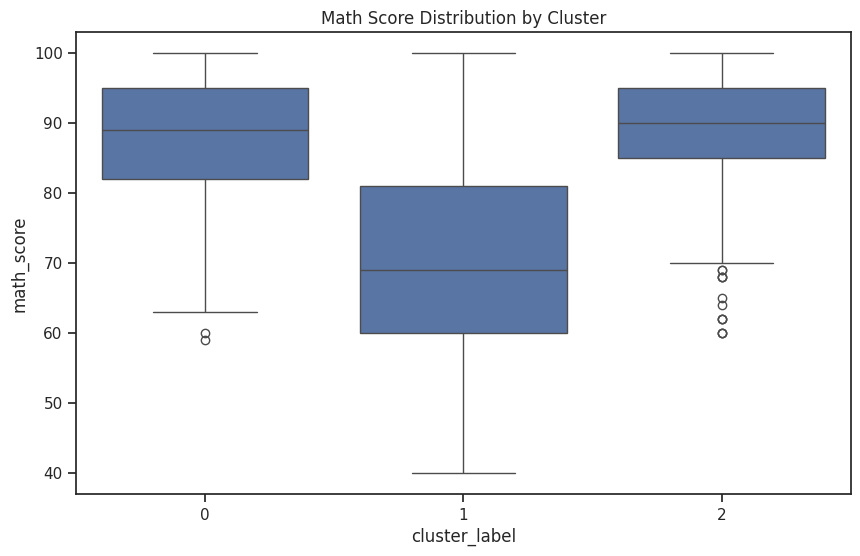

In [67]:
# Визуализация 2: Средние баллы по кластерам (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster_label', y='math_score', data=df)
plt.title('Math Score Distribution by Cluster')
plt.show()

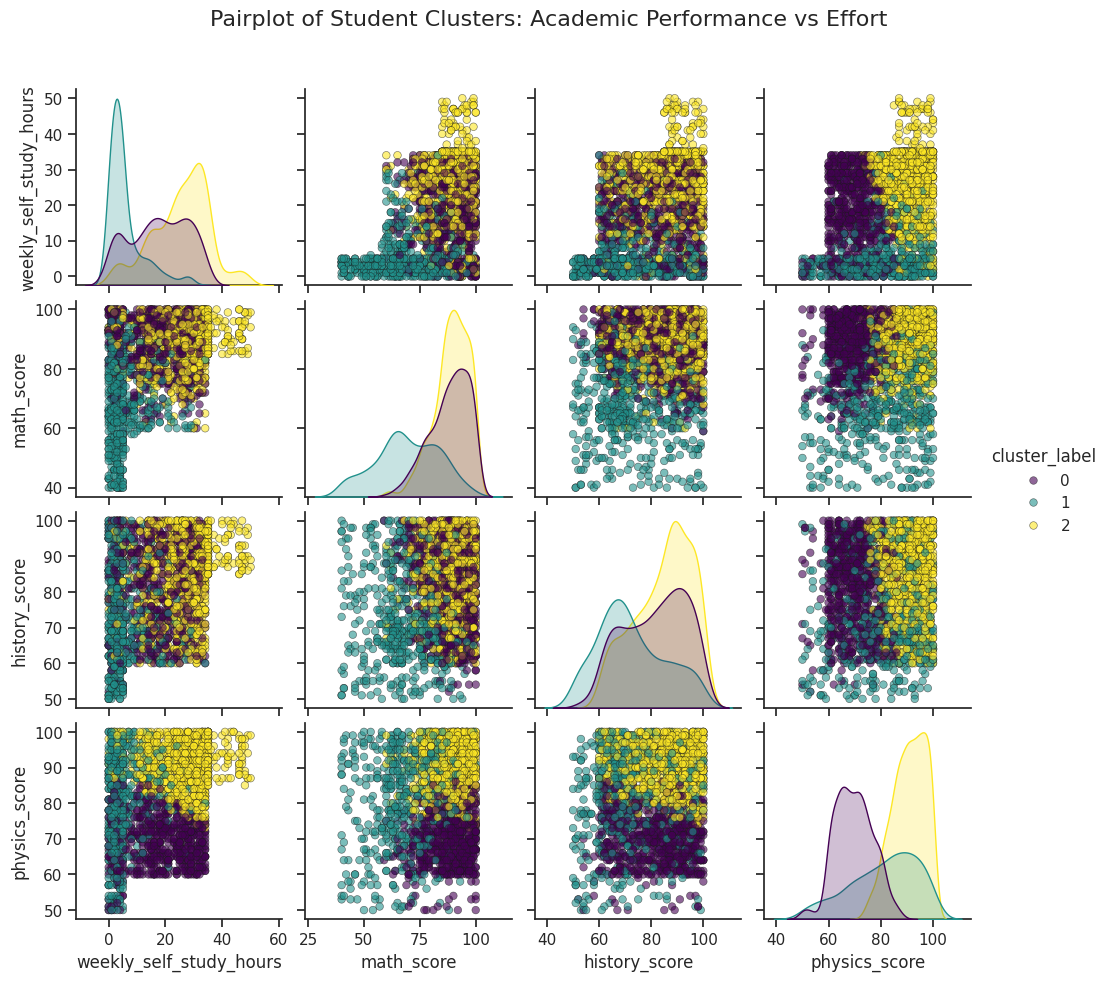

In [68]:
# Используем pairplot для визуализации всех выбранных признаков
# hue='cluster_label' раскрасит точки в цвета твоих кластеров
sns.set(style="ticks")
pp = sns.pairplot(df, 
                  vars=['weekly_self_study_hours', 'math_score', 'history_score', 'physics_score'], 
                  hue='cluster_label', 
                  palette='viridis', 
                  diag_kind='kde', # Рисует графики плотности на диагонали
                  plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})

plt.subplots_adjust(top=0.9)
pp.fig.suptitle('Pairplot of Student Clusters: Academic Performance vs Effort', fontsize=16)
plt.show()